# Krusell-Smith Model

(The content of this notebook draws partially on `krusell_smith.md` in the Guides section of HARK's online documentation.)

The Krusell-Smith model is a heterogeneous agent macroeconomic model that examines how individual income and wealth heterogeneity affects aggregate economic outcomes. In this model, households face idiosyncratic employment shocks in an economy with aggregate productivity shocks that follow a Markov process.

HARK's implementation provides tools for both solving the individual household problem and finding the general equilibrium aggregate saving rule through simulation and regression methods.

In [1]:
# Import stuff from HARK and Python tools
from HARK.ConsumptionSaving.ConsAggShockModel import (
    KrusellSmithType,
    KrusellSmithEconomy,
)
import numpy as np
import matplotlib.pyplot as plt
from HARK.utilities import plot_funcs, plot_func_slices
from time import time

mystr = lambda x: "{:.4f}".format(x)

## Model Overview

The `KrusellSmithType` class represents individual agents in the Krusell-Smith economy. This class is found in `HARK.ConsumptionSaving.ConsAggShockModel`.

**Key Features:**

- Agents face idiosyncratic employment shocks
- Aggregate state follows a two-state Markov process (bad=0, good=1)
- Agents form expectations about aggregate capital based on perceived aggregate market resources
- Uses specialized solution methods optimized for the KS structure

The `KrusellSmithEconomy` class represents the macroeconomic environment in which `KrusellSmithType` agents live. This is a subclass of `Market` that implements the aggregate dynamics and equilibrium computation.

**Key Features:**

- Two-state Markov process for aggregate productivity (good/bad)
- State-dependent unemployment rates
- Computes equilibrium aggregate saving rules
- Simulates aggregate economic history

A `KrusellSmithType` instance must be used in conjunction with a `KrusellSmithEconomy` instance, with the `KrusellSmithType` specified as the economy's `agents`. Use the `give_agent_params()` method to distribute economy-determined objects into the agent.

## Model Statement

The classic Krusell-Smith model is a stripped down, highly specific version of our more general `AggShockMarkov` model. In particular, the nature of risk is very limited. At the aggregate level, there is a binary discrete state $s_t$ that follows a Markov process. In the "bad" economic state, aggregate productivity $z$ is lower, unemployment is higher, and unemployment spells last longer on average (unemployment is "stickier"). In the "good" economic state, aggregate productivity is higher and unemployment is lower (and is less persistent). At the idiosyncratic level, employment $e_{it}$ is the only source of additional uncertainty, and consumers receive no non-capital income when unemployed.

The model is intended strictly for infinite horizon "perpetual youth" consumers, and there is no mortality at all. It was designed to be the simplest or most straightforward heterogeneous agents model with aggregate uncertainty and a non-trivial distribution of wealth. The microeconomic model can be expressed as:

\begin{align*}
\text{v}(m_{it},e_{it};M_t,s_t) &= \max_{c_{it}} \frac{c_{it}^{1-\rho}}{1-\rho} + \beta \mathbb{E} \left[ \text{v}(m_{it+1},e_{it+1};M_t,s_{t+1}) \right] \\
& \text{s.t.} \\
a_{it} &= m_{it} - c_{it}, \\
a_{it} &\geq 0, \\
m_{it+1} &= \mathsf{R}_{t+1} a_{it} + \mathsf{w}_{t+1} \ell e_{it}, \\
A_t &= \mathbf{A}(M_t, s_t), \\
M_{t+1} &= \mathsf{R}_{t+1} A_{t} + \mathsf{w}_{t+1} \ell \mho_s, \\
s_{t+1} &\sim \text{Bernoulli}(\pi_s), \\
e_{it+1} &\sim \text{Bernoulli}(\xi_{ss'e}).
\end{align*}

Consumers in this model have parametric beliefs about the aggregate saving rule $\mathbf{A}(\cdot)$, which depends on aggregate market resources $M_t$ and the aggregate productivity state $s_t$. As for `AggShockConsumerType`s, beliefs about the aggregate saving rule are an object to be solved for in general equilibrium. As in our other models, the state-conditional aggregate saving rule is log-linear: $\log(A_t) = \kappa_0 + \kappa_1 \log(M_t)$.

The state-conditional unemployment rates $\mho_s$ and probabilities of realizing the good state $\pi_s$ are primitive parameters, while the idiosyncratic employment probabilities $\xi_{ss'e}$ are constructed so that the unemployment rate changes *instantly* from $\mho_0$ to $\mho_1$ (or vice versa) when the aggregate state $s_t$ flips. Idiosyncratic unemployment is persistent, with spells lasting $D_s$ periods on average (conditional on remaining in that aggregate state).

At the market level, output is produced according to a Cobb-Douglas production function over capital and labor (with capital's share denoted $\alpha$). Aggregate capital $K_t$ is supported by retained aggregate assets $A_t$, while aggregate labor $L_t$ is the current employment rate $\mho_s$ times exogenous labor supply per employed worker $\ell$.

Under the standard assumption that markets are competitive, the prices for each factor are equal to their marginal product. Moreover, capital depreciates at rate $\delta$ per period, so the net return to capital is one plus the interest rate less depreciation.

\begin{align*}
K_{t} &= \int a_{it-1} di, \\
L_{t} &= \ell \mho_s, \\
k_t &= K_t / L_t, \\
\mathsf{w}_t &= z_s (1-\alpha) k_t^{\alpha}, \\
\mathsf{r}_t &= z_s \alpha k_t^{-\alpha},\\ 
\mathsf{R}_t &= 1 - \delta + \mathsf{r}_t.
\end{align*}

## Default Parameters for Krusell-Smith Model

All of the default parameters for `KrusellSmithType` and `KrusellSmithEconomy` are taken directly from the original 1998 paper. The default parameters for the `AgentType` subclass are:

| Parameter | Description | Code | Value |
| :---: | --- | --- | --- |
| $\beta$ |Intertemporal discount factor  | `DiscFac` | $0.99$ |
| $\rho$ |Coefficient of relative risk aversion | `CRRA` | $1.0$ |
| $(none)$ | Minimum value in assets grid | `aMin` | $0.001$ | |
| $(none)$ | Maximum value in assets-above-minimum grid | `aMax` | $50.0$ |
| $(none)$ | Number of points in assets grid | `aXtraCount` | $32$ |
| $(none)$ | Exponential nesting factor for base assets grid | `aNestFac` | $2$ |
| $(none)$ | Number of aggregate $M_t$ gridpoints to use | `MaggCount` | $25$ |
| $(none)$ | Base perturbation factor around PF SS for grid of $M_t$ | `MaggPerturb` | $0.01$ |
| $(none)$ | Log scaling factor for additional $M_t$ gridpoints | `MaggExpFac` | $0.12$ |
| $(none)$ | Number of periods in cycle | `T_cycle` | $1$ |
| $(none)$ | Number of times to repeat cycle (infinite) | `cycles` | $0$ |

The grid of end-of-period assets $a_t$ is constructed identically to other HARK models. Normally, the lower bound of $a_t$ depends on the parameters, because most HARK models permit borrowing. In the Krusell-Smith model, however, the artificial borrowing constraint $a_t \geq 0$ is "hardwired" and so we label the assets grid as `aGrid` rather than `aXtraGrid`-- it's not "extra assets above minimum" but just "assets".

Most of the model parameters live at the `Market` level, specifying the aggregate productivity and employment process.

| Parameter | Description | Code | Value | 
| :---: | --- | --- | --- |
| $\delta$ | Capital depreciation rate  | `DeprRte` | $0.025$ |
| $\alpha$ | Capital's share of production | `CapShare` | $0.36$ |
| $\ell$ | Labor supply per employed worker | `LbrInd` | $0.3271$ |
| $\beta$ | Intertemporal discount factor (PF calibration) | `DiscFac` | $0.99$ |
| $\rho$ | Coefficient of relative risk aversion (PFcalibration) | `CRRA` | $1.0$ |
| $1/\pi_0$ | Expected duration of "bad" economic state | `DurMeanB` | $8.0$ |
| $1/\pi_1$ | Expected duration of "good" economic state | `DurMeanG` | $8.0$ |
| $z_0$ | Total factor productivity in "bad" state | `ProdB` | $0.99$ |
| $z_1$ | Total factor productivity in "good" state | `ProdG` | $1.01$ |
| $1-\mho_0$ | Unemployment rate in "bad" state | `UrateB` | $0.10$ |
| $1-\mho_1$ | Unemployment rate in "good" state | `UrateG` | $0.04$ |
| $D_0$ | Expected duration of unemployment spell in "bad" state | `SpellMeanB` | $2.5$ |
| $D_1$ | Expected duration of unemployment spell in "good" state | `SpellMeanG` | $1.5$ |
| $(none)$ | Relative persistence of unemployment when entering "bad" state | `RelProbGB` | $1.25$ |
| $(none)$ | Relative persistence of unemployment when entering "good" state | `RelProbBG` | $0.75$ |
| (none) | Damping factor when updating $\mathbf{A}(\cdot)$ (weight on prior value) | `DampingFac` | $0.1$ |
| $\kappa_0$ | Initial guess for intercept $\kappa_0$, intercept term in $\mathbf{A}(\cdot)$ | `intercept_prev` | $[0.0, 0.0]$ |
| $\kappa_1$ | Initial guess for intercept $\kappa_1$, slope coefficient for $\mathbf{A}(\cdot)$ | `slope_prev` | $[1.0, 1.0]$ |
| $s_0$ | Discrete Markov state at start of simulated history | `MrkvInit` | $0$ |
| (none) | Number of periods to simulate per history | `act_T` | $11000$ |
| (none) | Number of "burn in" periods to discard at start of simulation run | `T_discard` | $1000$ |
| (none) | Whether to print progress to screen when solving for equilibrium $\mathbf{A}(\cdot)$ | `verbose` | $False$ |

## Example Krusell-Smith Model Implementation

To make and solve the Krusell-Smith model, we must instantiate both a `KrusellSmithType` and a `KrusellSmithEconomy`, and then solve the latter. Our default parameters are the same as in the original 1998 paper, so let's just use those.

In [2]:
# Make the agents with default parameters, and put them into the economy
KSagents = KrusellSmithType(seed=0)
KSeconomy = KrusellSmithEconomy(agents=[KSagents], verbose=True)
KSeconomy.make_Mrkv_history()  # fix a history of aggregate shocks
KSeconomy.give_agent_params()  # distribute market-level parameters to the agents

In [3]:
# Solve the Krusell-Smith model
t0 = time()
KSeconomy.solve()
t1 = time()
print("Solving the Krusell-Smith model took " + mystr(t1 - t0) + " seconds.")

intercept=[-0.19575408115669643, -0.2044100979412641], slope=[1.0505905910892408, 1.0524897732582534], r-sq=[0.9996513537112532, 0.9998034160502358]
intercept=[-0.21532948927236606, -0.22485110773539052], slope=[1.0556496501981647, 1.0577387505840787], r-sq=[0.9996513537112532, 0.9998034160502358]
intercept=[-0.21728703008393302, -0.22689520871480315], slope=[1.0561555561090572, 1.0582636483166612], r-sq=[0.9996513537112532, 0.9998034160502358]
intercept=[-0.21748278416508973, -0.22709961881274443], slope=[1.0562061467001465, 1.0583161380899195], r-sq=[0.9996513537112532, 0.9998034160502358]
intercept=[-0.2175023595732054, -0.22712005982253855], slope=[1.0562112057592554, 1.0583213870672452], r-sq=[0.9996513537112532, 0.9998034160502358]
Solving the Krusell-Smith model took 141.5930 seconds.


The parametric aggregate saving rule is *very* accurate, with an $R^2$ of around $0.9997$ in both the "good" and "bad" macroeconomic states. Like for the `AggShockMarkovConsumerType`, we can plot the history of aggregate $M_t$ vs aggregate $A_t$ conditional on the discrete state.

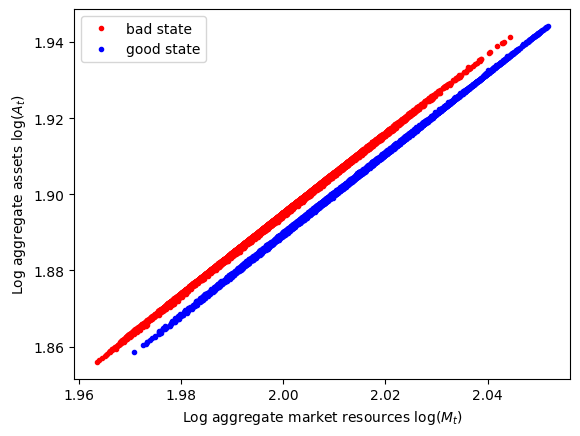

In [4]:
# Extract the history of M_t and A_t and plot them conditional on the discrete state
T0 = KSeconomy.T_discard
logAagg = np.log(KSeconomy.history["Aprev"][T0:])
logMagg = np.log(KSeconomy.history["Mnow"][T0 - 1 : -1])
z = KSeconomy.MrkvNow_hist[T0 - 1 : -1]

bad = z == 0
good = z == 1
plt.plot(logMagg[bad], logAagg[bad], ".r")
plt.plot(logMagg[good], logAagg[good], ".b")
plt.legend(["bad state", "good state"])
plt.xlabel(r"Log aggregate market resources $\log(M_t)$")
plt.ylabel(r"Log aggregate assets $\log(A_t)$")
plt.show()

The agents' solution is characterized by four state-conditional consumption functions: bad-unemployed, bad-employed, good-unemployed, and good-employed. Each of those four functions depends on both idiosyncratic $m_{it}$ and aggregate $M_t$ market resources, so we need to plot them on four different graphs:

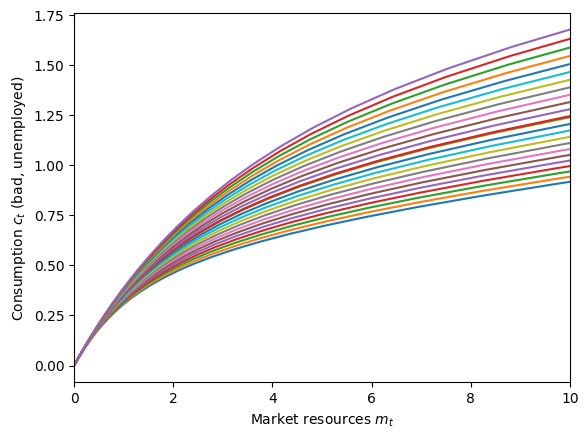

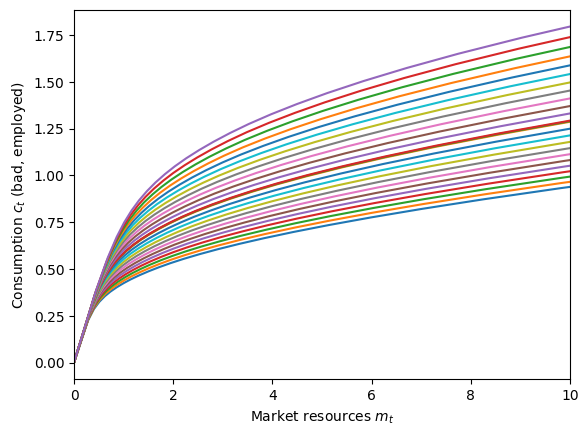

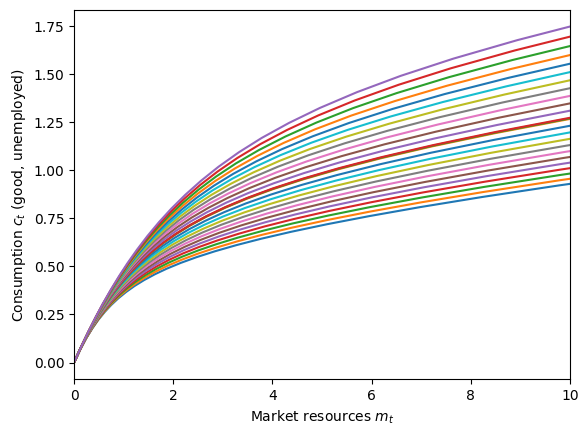

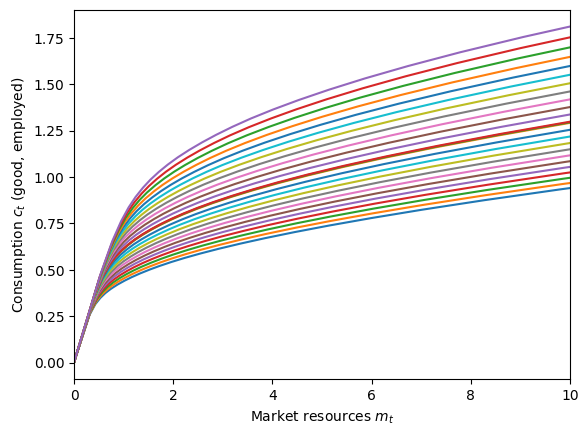

In [5]:
# Plot the state-conditional consumption functions
KSagents.unpack("cFunc")
state_names = ["bad, unemployed", "bad, employed", "good, unemployed", "good, employed"]
for j in range(4):
    plot_func_slices(
        KSagents.cFunc[0][j],
        0.0,
        10.0,
        Z=KSagents.Mgrid,
        xlabel=r"Market resources $m_t$",
        ylabel=r"Consumption $c_t$ (" + state_names[j] + ")",
    )

To more directly visualize the differences in the consumption function by discrete state, we can make a graph with all four functions, holding aggregate market resources $M_t$ fixed. Below, we set $M_t$ equal to the perfect foresight steady state level, but other levels will show the same pattern.

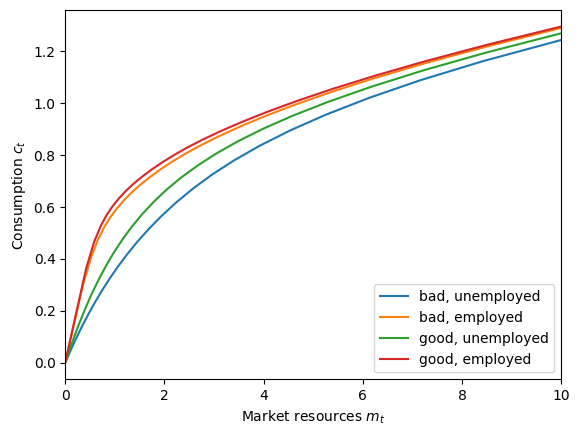

In [6]:
# Plot all four discrete-state conditional consumption functions on one graph
M = KSeconomy.MSS
C_funcs_by_z = [
    lambda m: KSagents.cFunc[0][0](m, M * np.ones_like(m)),
    lambda m: KSagents.cFunc[0][1](m, M * np.ones_like(m)),
    lambda m: KSagents.cFunc[0][2](m, M * np.ones_like(m)),
    lambda m: KSagents.cFunc[0][3](m, M * np.ones_like(m)),
]  # you might think this can be done with list comprehension, but it can't
plot_funcs(
    C_funcs_by_z,
    0.0,
    10.0,
    xlabel=r"Market resources $m_t$",
    ylabel=r"Consumption $c_t$",
    legend_kwds={"labels": state_names, "loc": 4},
)

Notice that the lowest consumption function is when the agent is unemployed and the economy is in the bad state (blue). In this situation, the agent expects to be unemployed for a significant time, so they want to consume even less than they would if they were unemployed in good times (green), preserving their resources for the future.

Likewise, the consumption function when employed in the bad state (orange) is below the consumption function when employed in the good state (red), but less dramatically so. In bad economic times, employed consumers foresee that it is more likely that they *will* soon become unemployed, and be unemployed for longer, than if times were good. Hence they want to save up a bit more as a buffer of wealth to finance future consumption.

These microeconomic behaviors are expressed on the plot of aggregate saving vs aggregate market resources above. Aggregate saving $A_t$ is higher in bad times for any level of aggregate market resources $M_t$. But *on average*, aggregate market resources (and aggregate assets) are *lower* in the bad state because the economy is less productive.